# US Diabetes Health Disparities — Feature Transformation

**Project:** US Diabetes Health Disparities Analysis  
**Notebook:** 02_feature_transformation.ipynb  
**Author:** Adam Bailes  
**Date:** July 2026  
**Purpose:** Clean, transform, and join PLACES and Census/ACS data 
into a single analysis-ready dataframe for disparity analysis

## How to Read This Notebook

Each code block in this notebook follows a consistent structure:

### Code Comments
Lines starting with `#` are comments — plain English explanations 
of what the code is doing. They are ignored by Python and exist 
purely for documentation.

### Explanation Cells
Each code block is accompanied by a Markdown cell (like this one) 
explaining:
- **What the code does** — the mechanics of each function or method
- **Why it is being done** — the analytical purpose and how it 
  connects to the research questions
- **What to look for in the output** — what a good result looks like 
  and what would signal a problem

### Key Python Concepts Used in This Notebook
- `pd.read_csv()` — loads a CSV file into a pandas DataFrame (a table)
- `df.shape` — returns the number of rows and columns
- `df.groupby()` — groups rows by a category for summary calculations
- `df.merge()` — joins two DataFrames on a shared column
- `df.isnull().sum()` — counts missing values per column
- `plt` / `sns` — matplotlib and seaborn, the visualization libraries
- `f'{value:.2f}'` — f-string formatting, embeds a variable value 
  into a string with 2 decimal places

### Variable Naming Convention
- `df` — the main analysis dataset (merged PLACES + Census)
- `df_*` — intermediate DataFrames (e.g., df_race, df_poverty)
- `fig, ax` — figure and axis objects for matplotlib charts

In [41]:
import pandas as pd

# Load filtered PLACES data
df_crude = pd.read_csv(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\02_data_acquisition\places_county_2025_filtered.csv'
)

# Load Census data
df_race = pd.read_csv(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\02_data_acquisition\census_race_2023.csv'
)
df_poverty = pd.read_csv(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\02_data_acquisition\census_poverty_2023.csv'
)
df_income = pd.read_csv(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\02_data_acquisition\census_income_2023.csv'
)

print('Files loaded')
print(f'PLACES: {df_crude.shape}')
print(f'Race: {df_race.shape}')
print(f'Poverty: {df_poverty.shape}')
print(f'Income: {df_income.shape}')

Files loaded
PLACES: (29580, 22)
Race: (3222, 9)
Poverty: (3222, 5)
Income: (3222, 3)


In [42]:
# Drop Loving County null rows (population < 50, estimates suppressed)
df_crude = df_crude.dropna(subset=['Data_Value'])

print(f'PLACES rows after dropping nulls: {df_crude.shape[0]}')

PLACES rows after dropping nulls: 29570


In [43]:
# Filter to crude prevalence only
df_crude = df_crude[df_crude['Data_Value_Type'] == 'Crude prevalence']

# Pivot to wide format — one row per county, one column per measure
df_wide = df_crude.pivot_table(
    index='LocationID',
    columns='MeasureId',
    values='Data_Value'
).reset_index()

print(df_wide.shape)
print(df_wide.head())

(2957, 6)
MeasureId  LocationID  BPHIGH  DIABETES  HIGHCHOL   LPA  OBESITY
0                  59    34.4      12.0      37.4  24.5     32.8
1                1001    42.0      13.3      41.3  27.0     39.8
2                1003    43.8      13.4      42.8  25.4     35.2
3                1005    50.2      19.6      43.0  36.2     46.8
4                1007    46.3      16.2      42.4  33.3     43.9


In [44]:
# Check data types of LocationID across all four dataframes
print(f'PLACES LocationID type: {df_wide["LocationID"].dtype}')
print(f'Race LocationID type: {df_race["LocationID"].dtype}')
print(f'Poverty LocationID type: {df_poverty["LocationID"].dtype}')
print(f'Income LocationID type: {df_income["LocationID"].dtype}')

PLACES LocationID type: int64
Race LocationID type: int64
Poverty LocationID type: int64
Income LocationID type: int64


In [45]:
# Check the actual values in LocationID across dataframes
print('PLACES:', df_wide['LocationID'].head())
print('Race:', df_race['LocationID'].head())

PLACES: 0      59
1    1001
2    1003
3    1005
4    1007
Name: LocationID, dtype: int64
Race: 0    1001
1    1003
2    1005
3    1007
4    1009
Name: LocationID, dtype: int64


In [46]:
# Convert LocationID to zero-padded 5-digit string in all four dataframes
# This restores the standard FIPS code format (e.g., 1001 becomes 01001)
df_wide['LocationID'] = df_wide['LocationID'].astype(str).str.zfill(5)
df_race['LocationID'] = df_race['LocationID'].astype(str).str.zfill(5)
df_poverty['LocationID'] = df_poverty['LocationID'].astype(str).str.zfill(5)
df_income['LocationID'] = df_income['LocationID'].astype(str).str.zfill(5)

# Confirm the fix
print('PLACES:', df_wide['LocationID'].head())
print('Race:', df_race['LocationID'].head())

PLACES: 0    00059
1    01001
2    01003
3    01005
4    01007
Name: LocationID, dtype: str
Race: 0    01001
1    01003
2    01005
3    01007
4    01009
Name: LocationID, dtype: str


In [47]:
# Join all four dataframes on LocationID
# Start with df_wide (PLACES) as the base
# Use left join to keep all PLACES counties as the anchor
df_merged = df_wide.merge(df_race, on='LocationID', how='left')
df_merged = df_merged.merge(df_poverty, on='LocationID', how='left')
df_merged = df_merged.merge(df_income, on='LocationID', how='left')

print(df_merged.shape)
print(df_merged.head())

(2957, 20)
  LocationID  BPHIGH  DIABETES  HIGHCHOL   LPA  OBESITY  \
0      00059    34.4      12.0      37.4  24.5     32.8   
1      01001    42.0      13.3      41.3  27.0     39.8   
2      01003    43.8      13.4      42.8  25.4     35.2   
3      01005    50.2      19.6      43.0  36.2     46.8   
4      01007    46.3      16.2      42.4  33.3     43.9   

                    NAME_x  pop_total  pop_white  pop_black  pop_aian  \
0                      NaN        NaN        NaN        NaN       NaN   
1  Autauga County, Alabama    59285.0    43616.0    11829.0      42.0   
2  Baldwin County, Alabama   239945.0   198721.0    19144.0     980.0   
3  Barbour County, Alabama    24757.0    10891.0    11616.0      46.0   
4     Bibb County, Alabama    22152.0    16634.0     4587.0     175.0   

   pop_asian  pop_nhpi  pop_multirace                   NAME_y  \
0        NaN       NaN            NaN                      NaN   
1      616.0       0.0         2722.0  Autauga County, Alabama 

In [48]:
# Drop the duplicate NAME columns from race and poverty dataframes
# Keep NAME from the income dataframe and rename it to county_name
df_merged = df_merged.drop(columns=['NAME_x', 'NAME_y'])
df_merged = df_merged.rename(columns={'NAME': 'county_name'})

# Drop rows with no Census match (unmatched PLACES counties)
unmatched = df_merged[df_merged['county_name'].isnull()]
print(f'Unmatched rows: {len(unmatched)}')
print(unmatched[['LocationID', 'DIABETES']])

# Drop unmatched rows
df_merged = df_merged.dropna(subset=['county_name'])
print(f'Rows after dropping unmatched: {df_merged.shape[0]}')

Unmatched rows: 1
  LocationID  DIABETES
0      00059      12.0
Rows after dropping unmatched: 2956


In [49]:
# Check for null values across all columns in the merged dataframe
print(df_merged.isnull().sum())


LocationID                 0
BPHIGH                     0
DIABETES                   0
HIGHCHOL                   0
LPA                        0
OBESITY                    0
pop_total                  0
pop_white                  0
pop_black                  0
pop_aian                   0
pop_asian                  0
pop_nhpi                   0
pop_multirace              0
pop_poverty_total          0
pop_below_poverty          0
pct_below_poverty          0
county_name                0
median_household_income    0
dtype: int64


In [50]:
# Calculate race percentages from raw counts
# Dividing each race count by total population and multiplying by 100
df_merged['pct_white'] = (df_merged['pop_white'] / df_merged['pop_total']) * 100
df_merged['pct_black'] = (df_merged['pop_black'] / df_merged['pop_total']) * 100
df_merged['pct_aian'] = (df_merged['pop_aian'] / df_merged['pop_total']) * 100
df_merged['pct_asian'] = (df_merged['pop_asian'] / df_merged['pop_total']) * 100
df_merged['pct_nhpi'] = (df_merged['pop_nhpi'] / df_merged['pop_total']) * 100
df_merged['pct_multirace'] = (df_merged['pop_multirace'] / df_merged['pop_total']) * 100

# Preview the new columns
print(df_merged[['county_name', 'pct_white', 'pct_black', 'pct_aian', 
                  'pct_asian', 'pct_nhpi', 'pct_multirace']].head())

               county_name  pct_white  pct_black  pct_aian  pct_asian  \
1  Autauga County, Alabama  73.570043  19.952771  0.070844   1.039049   
2  Baldwin County, Alabama  82.819396   7.978495  0.408427   0.946884   
3  Barbour County, Alabama  43.991598  46.920063  0.185806   0.549340   
4     Bibb County, Alabama  75.090285  20.706934  0.789996   0.230228   
5   Blount County, Alabama  89.492680   1.259866  0.396344   0.086015   

   pct_nhpi  pct_multirace  
1  0.000000       4.591381  
2  0.043343       5.536269  
3  0.000000       2.952700  
4  0.000000       2.821416  
5  0.148418       5.150779  


In [51]:
bins = [0, 10, 25, 50, 100]
labels = ['0-10%', '10-25%', '25-50%', '50%+']
df_merged['race_bin'] = pd.cut(df_merged['pct_black'], bins=bins, labels=labels, include_lowest=True)

In [52]:
from census import Census

# Reconnect to Census API
api_key = '18b6f04b3b026ec208981ae2d9a98049393932b8'
c = Census(api_key)

print('Census API connected')

Census API connected


In [53]:
# Pull Hispanic/Latino ethnicity data from ACS 5-year estimates (2023)
# B03003 is the Census table for Hispanic or Latino origin
hispanic_data = c.acs5.get(
    ('NAME',
     'B03003_001E',  # Total population
     'B03003_003E'), # Hispanic or Latino
    {'for': 'county:*', 'in': 'state:*'},
    year=2023
)

print(f'Rows returned: {len(hispanic_data)}')
print(hispanic_data[0])

Rows returned: 3222
{'NAME': 'Autauga County, Alabama', 'B03003_001E': 59285.0, 'B03003_003E': 2188.0, 'state': '01', 'county': '001'}


In [54]:
# Convert to DataFrame
df_hispanic = pd.DataFrame(hispanic_data)

# Build 5-digit FIPS code and zero-pad to match LocationID format
df_hispanic['LocationID'] = (df_hispanic['state'] + df_hispanic['county']).str.zfill(5)

# Calculate Hispanic percentage
df_hispanic['pct_hispanic'] = (df_hispanic['B03003_003E'] / df_hispanic['B03003_001E']) * 100

# Rename raw count columns
df_hispanic = df_hispanic.rename(columns={
    'B03003_001E': 'pop_total_hispanic_base',
    'B03003_003E': 'pop_hispanic'
})

# Drop separate state and county columns
df_hispanic = df_hispanic.drop(columns=['state', 'county'])

print(df_hispanic.shape)
print(df_hispanic.head())


(3222, 5)
                      NAME  pop_total_hispanic_base  pop_hispanic LocationID  \
0  Autauga County, Alabama                  59285.0        2188.0      01001   
1  Baldwin County, Alabama                 239945.0       13393.0      01003   
2  Barbour County, Alabama                  24757.0        1490.0      01005   
3     Bibb County, Alabama                  22152.0         744.0      01007   
4   Blount County, Alabama                  59292.0        5962.0      01009   

   pct_hispanic  
0      3.690647  
1      5.581696  
2      6.018500  
3      3.358613  
4     10.055319  


In [55]:
# Join Hispanic percentage to the merged dataframe
# Keep only LocationID and pct_hispanic from df_hispanic
df_merged = df_merged.merge(
    df_hispanic[['LocationID', 'pct_hispanic']],
    on='LocationID',
    how='left'
)

# Confirm shape and check for nulls in the new column
print(df_merged.shape)
print(f'Null values in pct_hispanic: {df_merged["pct_hispanic"].isnull().sum()}')

(2956, 26)
Null values in pct_hispanic: 0


In [56]:
# Save the merged dataframe to the data acquisition folder
df_merged.to_csv(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\02_data_acquisition\merged_analysis_ready.csv',
    index=False
)

print('Merged file saved')
print(df_merged.shape)

Merged file saved
(2956, 26)


In [57]:
# Print all column names in the merged dataframe
print(df_merged.columns.tolist())

['LocationID', 'BPHIGH', 'DIABETES', 'HIGHCHOL', 'LPA', 'OBESITY', 'pop_total', 'pop_white', 'pop_black', 'pop_aian', 'pop_asian', 'pop_nhpi', 'pop_multirace', 'pop_poverty_total', 'pop_below_poverty', 'pct_below_poverty', 'county_name', 'median_household_income', 'pct_white', 'pct_black', 'pct_aian', 'pct_asian', 'pct_nhpi', 'pct_multirace', 'race_bin', 'pct_hispanic']


NOTE: race variable names

- pct_white — White alone (non-Hispanic White is a separate calculation requiring the B03003 Hispanic table)
- pct_black — Black or African American alone
- pct_aian — American Indian and Alaska Native alone
- pct_asian — Asian alone
- pct_nhpi — Native Hawaiian and Other Pacific Islander alone
- pct_multirace — Two or more races

In [58]:
# Save Hispanic data pull to 02_data_acquisition
df_hispanic.to_csv(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\02_data_acquisition\census_hispanic_2023.csv',
    index=False
)

print('Hispanic data saved')

Hispanic data saved


In [59]:
# Create income quintile variable
# Divides counties into 5 equal groups from lowest to highest income
df_merged['income_quintile'] = pd.qcut(
    df_merged['median_household_income'],
    q=5,                                                          # q=5 specifies 5 equal groups
    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)']
)

# Confirm the distribution across quintiles
print(df_merged['income_quintile'].value_counts().sort_index())

income_quintile
Q1 (Lowest)     592
Q2              591
Q3              591
Q4              591
Q5 (Highest)    591
Name: count, dtype: int64


## Feature Transformation Steps Completed

### Data Loading
- Loaded PLACES filtered CSV, three Census CSVs from 02_data_acquisition
- Dropped Loving County null rows (10 rows)
- Filtered to crude prevalence only
- Pivoted PLACES from long to wide format

### Joining
- Zero-padded LocationID to 5-digit FIPS string across all dataframes
- Left joined PLACES, race, poverty, income, and Hispanic data on LocationID
- Dropped one unmatched row (LocationID 00059)
- Final merged dataframe: 2,956 rows, 25 columns

### Derived Variables
- pct_white, pct_black, pct_aian, pct_asian, pct_nhpi, pct_multirace
  calculated from raw Census counts
- pct_hispanic pulled directly from B03003
- income_quintile created from median_household_income (5 equal groups)

### Saved Files
- merged_analysis_ready.csv — joined analysis-ready dataset
- census_hispanic_2023.csv — Hispanic/Latino data pull

## Linearity Check — Residual Plots

Residual plots are used to verify whether the relationship between each 
predictor and DIABETES is linear before proceeding to regression modeling.

**Method:** A simple linear regression is fitted between each predictor 
and DIABETES. The residuals (difference between actual and predicted values) 
are plotted against the fitted values.

**Interpreting the plots:**
- Random scatter around zero = linear relationship, assumption holds
- Systematic curve or pattern = non-linearity present, polynomial terms 
  or transformation may be needed
- Fan shape (residuals spread wider at higher values) = heteroscedasticity,
  a separate assumption violation worth noting

**Note:** Non-linearity at higher burden levels is plausible given 
compounding risk factors in high-deprivation counties. This check 
was flagged in 01_eda.ipynb before assuming linearity.

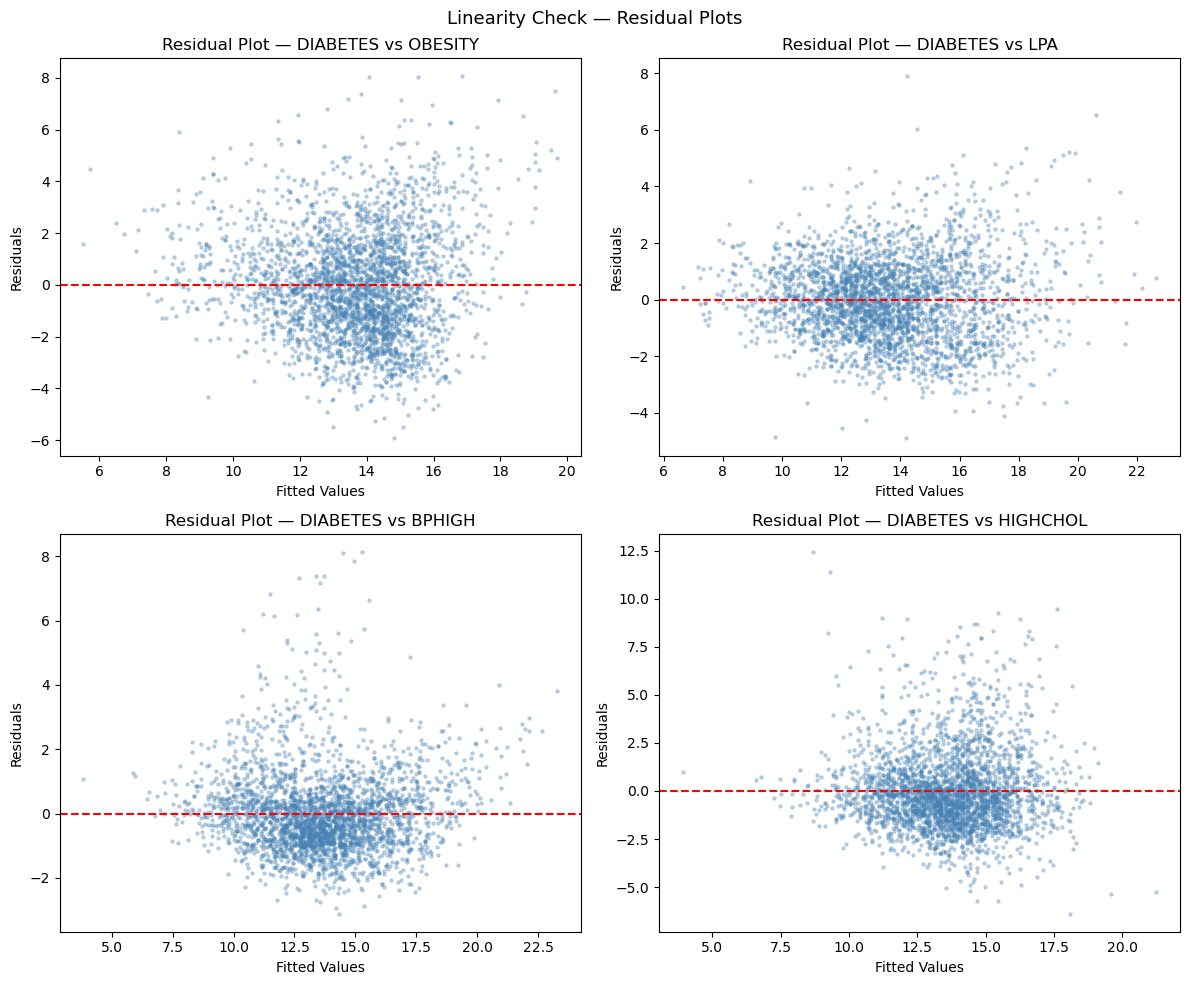

Chart saved


In [60]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Define predictors to check
predictors = ['OBESITY', 'LPA', 'BPHIGH', 'HIGHCHOL']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, predictor in enumerate(predictors):
    # Fit simple linear regression
    X = df_merged[[predictor]]
    y = df_merged['DIABETES']
    
    model = LinearRegression()
    model.fit(X, y)
    
    # Calculate residuals
    y_pred = model.predict(X)
    residuals = y - y_pred
    
    # Plot residuals against fitted values
    axes[i].scatter(y_pred, residuals, alpha=0.3, s=5, color='steelblue')
    axes[i].axhline(0, color='red', linestyle='dashed')
    axes[i].set_xlabel('Fitted Values')
    axes[i].set_ylabel('Residuals')
    axes[i].set_title(f'Residual Plot — DIABETES vs {predictor}')

plt.suptitle('Linearity Check — Residual Plots', fontsize=13)
plt.tight_layout()
plt.savefig(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\04_reporting\residual_plots.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Chart saved')

## Linearity Check — Findings

- **OBESITY:** Fan shape visible — heteroscedasticity present
- **LPA:** Acceptable — residuals reasonably random around zero
- **BPHIGH:** Clear C-shaped curve — non-linearity present; straight 
  line under-predicts at extremes and over-predicts in mid-range
- **HIGHCHOL:** Fan shape — moderate heteroscedasticity

**Implication:** LPA is suitable for linear regression as-is. 
BPHIGH shows the most serious non-linearity and will require a 
polynomial term or log transformation before inclusion in the 
multivariate model. OBESITY and HIGHCHOL may also benefit from 
transformation. To be addressed in 04_multivariate_analysis.ipynb.

In [61]:
# Resave merged dataframe with income_quintile column added
df_merged.to_csv(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\02_data_acquisition\merged_analysis_ready.csv',
    index=False
)

print('Merged file resaved with income_quintile')
print(df_merged.shape)

Merged file resaved with income_quintile
(2956, 27)


In [62]:
# Load NCHS urban-rural classification file
# latin-1 encoding handles special characters in county names
df_urban = pd.read_csv(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\02_data_acquisition\NCHSurb-rural-codes.csv',
    encoding='latin-1'
)

print(df_urban.shape)
print(df_urban.head())

(3160, 11)
   STFIPS  CTYFIPS ST_ABBREV         CTYNAME                  CBSATITLE  \
0       1        1        AL  Autauga County             Montgomery, AL   
1       1        3        AL  Baldwin County  Daphne-Fairhope-Foley, AL   
2       1        5        AL  Barbour County             Eufaula, AL-GA   
3       1        7        AL     Bibb County             Birmingham, AL   
4       1        9        AL   Blount County             Birmingham, AL   

     CBSAPOP    CTYPOP  CODE2023  CODE2013  CODE2006  CODE1990  
0   385460.0   59759.0       3.0       3.0       3.0       3.0  
1   246435.0  246435.0       4.0       4.0       5.0       3.0  
2    26955.0   24706.0       5.0       6.0       5.0       5.0  
3  1181196.0   22005.0       2.0       2.0       2.0       6.0  
4  1181196.0   59512.0       2.0       2.0       2.0       3.0  


In [63]:
# Build 5-digit FIPS code from STFIPS and CTYFIPS
# STFIPS zero-padded to 2 digits, CTYFIPS to 3 digits
df_urban['LocationID'] = (
    df_urban['STFIPS'].astype(str).str.zfill(2) + 
    df_urban['CTYFIPS'].astype(str).str.zfill(3)
)

# Keep only the columns needed for the analysis
df_urban = df_urban[['LocationID', 'CTYNAME', 'CODE2023']]

# Rename CODE2023 to a more readable name
df_urban = df_urban.rename(columns={'CODE2023': 'urban_rural_code'})

# Add a text label column for the numeric code
urban_labels = {
    1.0: 'Large central metro',
    2.0: 'Large fringe metro',
    3.0: 'Medium metro',
    4.0: 'Small metro',
    5.0: 'Micropolitan',
    6.0: 'Noncore (rural)'
}
df_urban['urban_rural'] = df_urban['urban_rural_code'].map(urban_labels)

print(df_urban.shape)
print(df_urban.head())

(3160, 4)
  LocationID         CTYNAME  urban_rural_code         urban_rural
0      01001  Autauga County               3.0        Medium metro
1      01003  Baldwin County               4.0         Small metro
2      01005  Barbour County               5.0        Micropolitan
3      01007     Bibb County               2.0  Large fringe metro
4      01009   Blount County               2.0  Large fringe metro


In [64]:
# Join urban-rural classification to the merged dataframe
df_merged = df_merged.merge(
    df_urban[['LocationID', 'urban_rural_code', 'urban_rural']],
    on='LocationID',
    how='left'
)

# Check for nulls in the new columns
print(f'Shape after join: {df_merged.shape}')
print(f'Null values in urban_rural: {df_merged["urban_rural"].isnull().sum()}')
print(df_merged[['LocationID', 'county_name', 'urban_rural']].head())

Shape after join: (2956, 29)
Null values in urban_rural: 0
  LocationID              county_name         urban_rural
0      01001  Autauga County, Alabama        Medium metro
1      01003  Baldwin County, Alabama         Small metro
2      01005  Barbour County, Alabama        Micropolitan
3      01007     Bibb County, Alabama  Large fringe metro
4      01009   Blount County, Alabama  Large fringe metro


In [65]:
# Resave merged dataframe with urban_rural columns added
df_merged.to_csv(
    r'C:\Users\adamt\Jobs\Personal_Projects\US_Diabetes_Disparities\02_data_acquisition\merged_analysis_ready.csv',
    index=False
)

print('Merged file resaved with urban_rural classification')
print(df_merged.shape)

Merged file resaved with urban_rural classification
(2956, 29)
